## 5.5 YOLOv8n — Détection des véhicules BridgeGuard

- **Modèle** : YOLOv8n (nano détection)
- **Dataset** : Car Detection and Tracking Dataset (Kaggle)
- **Objectif** : Détecter les véhicules sur le pont avant fermeture barrière
- **Plateforme** : Kaggle GPU Tesla T4

In [1]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames[:10]:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/amitkumargurjar/car-detection-and-tracking-dataset/archive/classes.txt
/kaggle/input/datasets/amitkumargurjar/car-detection-and-tracking-dataset/archive/val/labels/frame_0475.txt
/kaggle/input/datasets/amitkumargurjar/car-detection-and-tracking-dataset/archive/val/labels/frame_0445.txt
/kaggle/input/datasets/amitkumargurjar/car-detection-and-tracking-dataset/archive/val/labels/frame_0465.txt
/kaggle/input/datasets/amitkumargurjar/car-detection-and-tracking-dataset/archive/val/labels/frame_0474.txt
/kaggle/input/datasets/amitkumargurjar/car-detection-and-tracking-dataset/archive/val/labels/frame_0459.txt
/kaggle/input/datasets/amitkumargurjar/car-detection-and-tracking-dataset/archive/val/labels/frame_0418.txt
/kaggle/input/datasets/amitkumargurjar/car-detection-and-tracking-dataset/archive/val/labels/frame_0472.txt
/kaggle/input/datasets/amitkumargurjar/car-detection-and-tracking-dataset/archive/val/labels/frame_0420.txt
/kaggle/input/datasets/amitkumargurjar/car

## 5.5.1 Dataset — Exploration et visualisation

Le dataset est déjà structuré au format YOLOv8 avec train/val séparés.
On explore le contenu et on visualise quelques exemples annotés.

In [2]:
import os
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches

BASE_PATH  = "/kaggle/input/datasets/amitkumargurjar/car-detection-and-tracking-dataset/archive"
TRAIN_IMG  = f"{BASE_PATH}/train/images"
TRAIN_LBL  = f"{BASE_PATH}/train/labels"
VAL_IMG    = f"{BASE_PATH}/val/images"

# Compter les fichiers
train_imgs = sorted(os.listdir(TRAIN_IMG))
val_imgs   = sorted(os.listdir(VAL_IMG))

print(f"Train images : {len(train_imgs)}")
print(f"Val images   : {len(val_imgs)}")
print(f"Total        : {len(train_imgs) + len(val_imgs)}")

# Lire les classes
with open(f"{BASE_PATH}/classes.txt") as f:
    classes = f.read().splitlines()
print(f"Classes      : {classes}")

Train images : 400
Val images   : 99
Total        : 499
Classes      : ['car']


## Visualisation des annotations

On affiche 6 images avec leurs bounding boxes pour vérifier
la qualité des annotations avant l'entraînement.

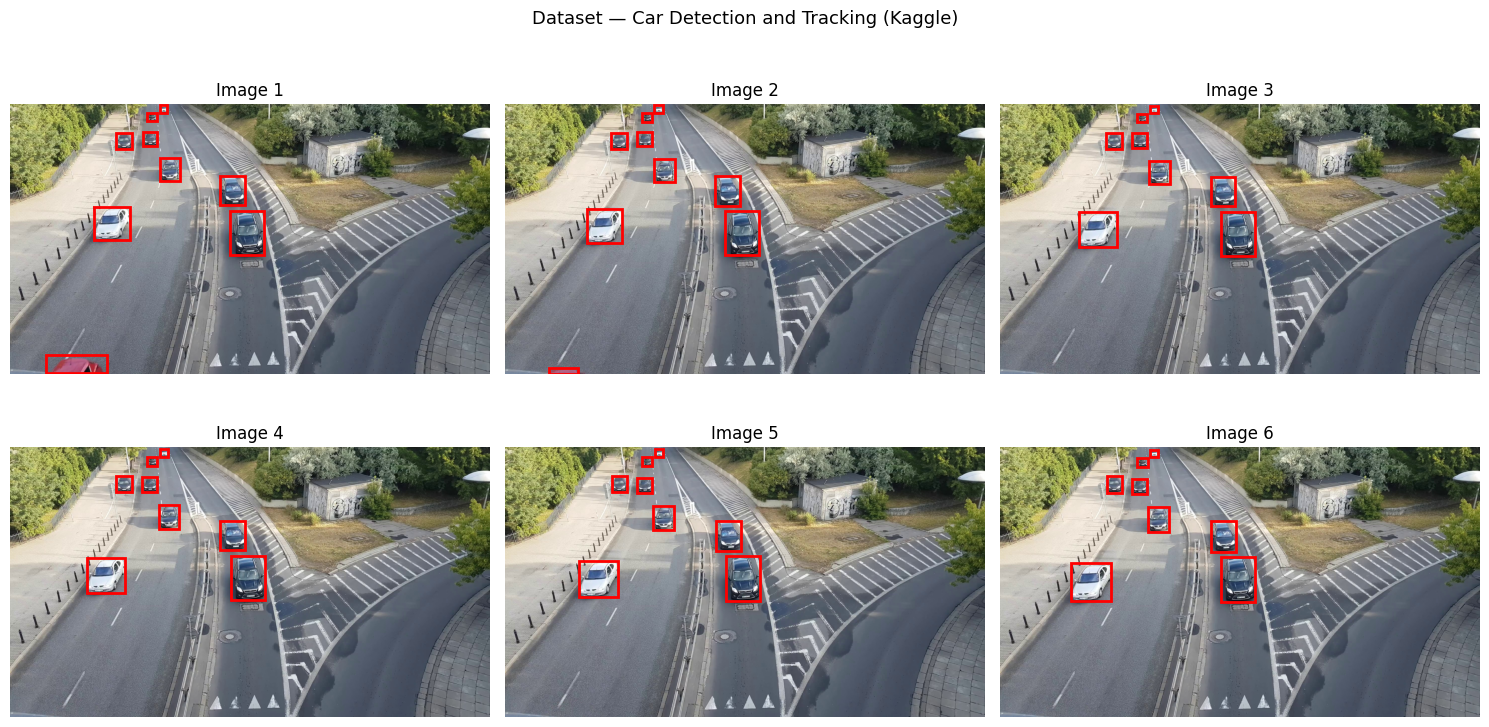

In [3]:
def draw_yolo_boxes(img_path, label_path, classes):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    fig, ax = plt.subplots(1, figsize=(8, 5))
    ax.imshow(img)

    if os.path.exists(label_path):
        with open(label_path) as f:
            for line in f:
                parts  = line.strip().split()
                cls_id = int(parts[0])
                cx, cy, bw, bh = map(float, parts[1:5])
                x1 = (cx - bw/2) * w
                y1 = (cy - bh/2) * h
                rect = patches.Rectangle(
                    (x1, y1), bw*w, bh*h,
                    linewidth=2, edgecolor="red", facecolor="none")
                ax.add_patch(rect)
                ax.text(x1, y1-5,
                    classes[cls_id] if cls_id < len(classes) else str(cls_id),
                    color="red", fontsize=9)
    ax.axis("off")
    return fig

# Visualiser 6 images
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Dataset — Car Detection and Tracking (Kaggle)", fontsize=13)

for i, ax in enumerate(axes.flat):
    img_name   = train_imgs[i]
    img_path   = f"{TRAIN_IMG}/{img_name}"
    label_path = f"{TRAIN_LBL}/{img_name.replace('.jpg', '.txt')}"
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    ax.imshow(img)
    if os.path.exists(label_path):
        with open(label_path) as f:
            for line in f:
                parts  = line.strip().split()
                cls_id = int(parts[0])
                cx, cy, bw, bh = map(float, parts[1:5])
                x1 = (cx - bw/2) * w
                y1 = (cy - bh/2) * h
                rect = patches.Rectangle(
                    (x1, y1), bw*w, bh*h,
                    linewidth=2, edgecolor="red", facecolor="none")
                ax.add_patch(rect)
    ax.set_title(f"Image {i+1}")
    ax.axis("off")

plt.tight_layout()
plt.savefig("dataset_cars.png", dpi=150, bbox_inches="tight")
plt.show()

## 5.5.2 Configuration data.yaml

YOLOv8 nécessite un fichier data.yaml pour localiser les données
et définir les classes à détecter.

In [4]:
# Lire les classes du dataset
with open(f"{BASE_PATH}/classes.txt") as f:
    classes = f.read().splitlines()

yaml_content = f"""
path: {BASE_PATH}
train: train/images
val: val/images

nc: {len(classes)}
names: {classes}
"""

with open("/kaggle/working/car_data.yaml", "w") as f:
    f.write(yaml_content)

print("✅ data.yaml créé !")
print(yaml_content)

✅ data.yaml créé !

path: /kaggle/input/datasets/amitkumargurjar/car-detection-and-tracking-dataset/archive
train: train/images
val: val/images

nc: 1
names: ['car']



## Entraînement — YOLOv8n détection véhicules

On entraîne YOLOv8n avec transfer learning depuis les poids COCO.
Le modèle nano est choisi pour sa compatibilité Raspberry Pi.

In [5]:
!pip install ultralytics -q
from ultralytics import YOLO
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"GPU : {torch.cuda.get_device_name(0)}")

model   = YOLO("yolov8n.pt")
results = model.train(
    data    = "/kaggle/working/car_data.yaml",
    epochs  = 50,
    imgsz   = 640,
    batch   = 16,
    device  = device,
    patience= 10,
    name    = "bridgegarde_vehicle_det",
    plots   = True
)
print("✅ Entraînement terminé !")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.4 MB/s eta 0:00:00a 0:00:01
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
GPU : Tesla T4
Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/car_data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.

## 5.5.3 Résultats — Courbes d'entraînement
On visualise l'évolution de la Loss et du mAP pendant les 50 epochs.

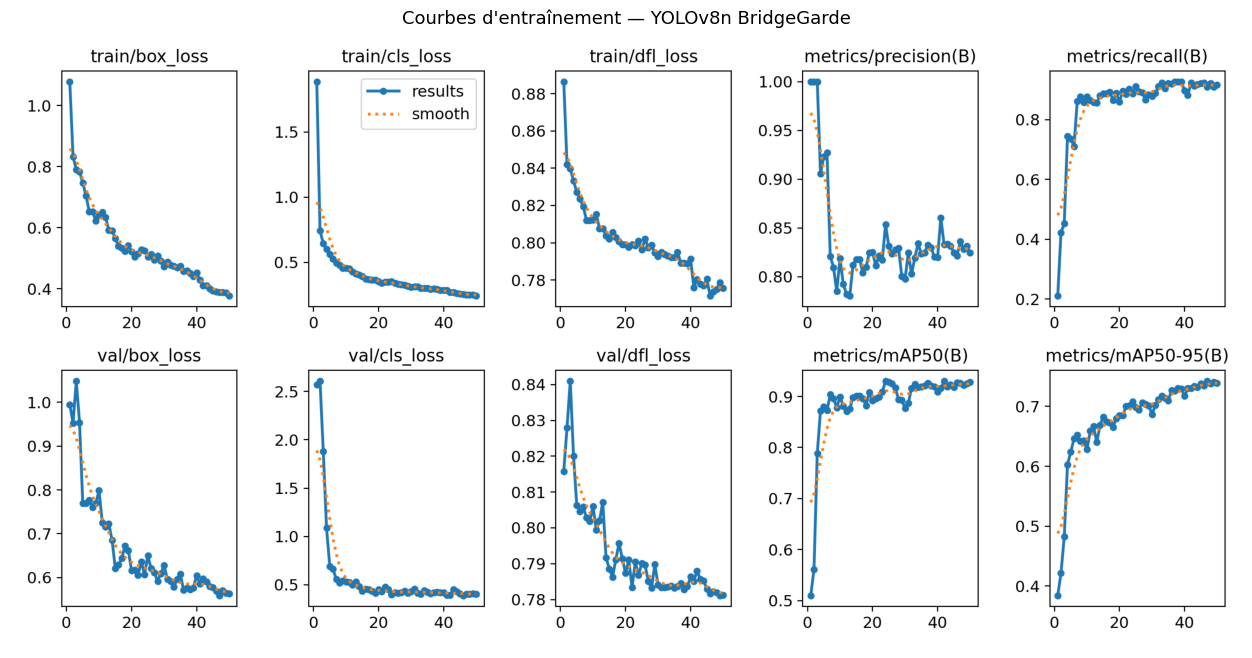

In [6]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

results_dir = "/kaggle/working/runs/detect/bridgegarde_vehicle_det"

img = mpimg.imread(f"{results_dir}/results.png")
plt.figure(figsize=(16, 8))
plt.imshow(img)
plt.axis("off")
plt.title("Courbes d'entraînement — YOLOv8n BridgeGarde", fontsize=13)
plt.savefig("training_curves_vehicles.png", dpi=150, bbox_inches="tight")
plt.show()

## Matrice de confusion

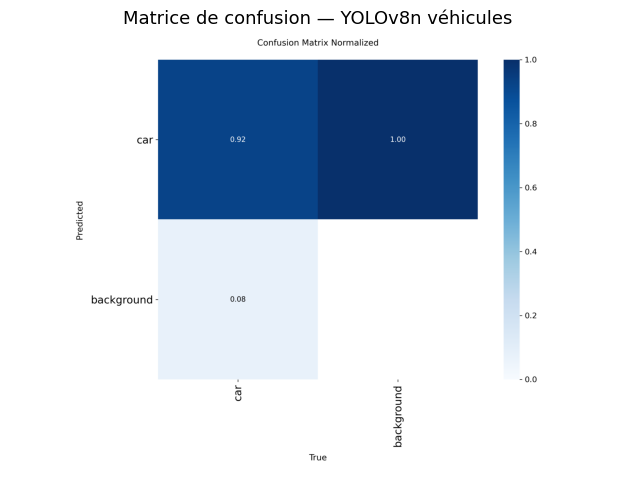

In [7]:
conf = mpimg.imread(f"{results_dir}/confusion_matrix_normalized.png")
plt.figure(figsize=(8, 6))
plt.imshow(conf)
plt.axis("off")
plt.title("Matrice de confusion — YOLOv8n véhicules", fontsize=13)
plt.savefig("confusion_matrix_vehicles.png", dpi=150, bbox_inches="tight")
plt.show()

## Prédictions sur images test
On teste le meilleur modèle sur 4 images pour visualiser
qualitativement les performances de détection.

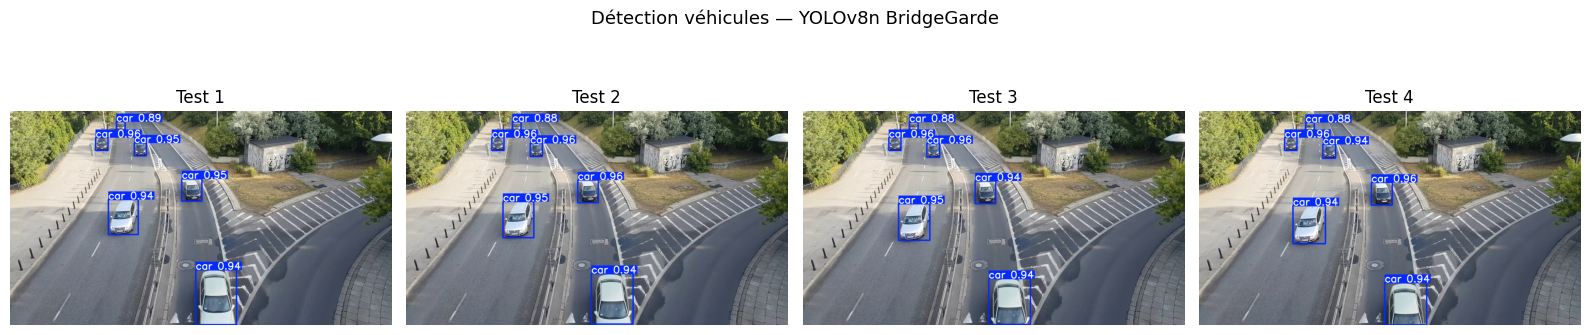

In [8]:
from ultralytics import YOLO
import os

best_model  = YOLO(f"{results_dir}/weights/best.pt")
val_images  = sorted(os.listdir(
    "/kaggle/input/datasets/amitkumargurjar/car-detection-and-tracking-dataset/archive/val/images"
))[:4]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Détection véhicules — YOLOv8n BridgeGarde", fontsize=13)

for idx, img_name in enumerate(val_images):
    img_path = f"/kaggle/input/datasets/amitkumargurjar/car-detection-and-tracking-dataset/archive/val/images/{img_name}"
    result   = best_model.predict(img_path, conf=0.5, verbose=False)[0]
    res_img  = result.plot()
    axes[idx].imshow(res_img[:, :, ::-1])
    axes[idx].set_title(f"Test {idx+1}")
    axes[idx].axis("off")

plt.tight_layout()
plt.savefig("detection_results.png", dpi=150, bbox_inches="tight")
plt.show()

## Métriques finales sur jeu de validation

In [9]:
metrics = best_model.val(
    data   = "/kaggle/working/car_data.yaml",
    verbose= False
)

print("=" * 45)
print("Métriques finales — YOLOv8n BridgeGuard")
print("=" * 45)
print(f"Précision  (P)  : {metrics.box.p[0]:.3f}")
print(f"Rappel     (R)  : {metrics.box.r[0]:.3f}")
print(f"mAP50           : {metrics.box.map50:.3f}")
print(f"mAP50-95        : {metrics.box.map:.3f}")
print("=" * 45)

Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.3±0.6 ms, read: 970.4±300.6 MB/s, size: 772.1 KB)
val: Scanning /kaggle/input/datasets/amitkumargurjar/car-detection-and-tracking-dataset/archive/val/labels... 99 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 99/99 745.7it/s 0.1s0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/amitkumargurjar/car-detection-and-tracking-dataset/archive/val is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 3.2it/s 2.2s0.2s
                   all         99        644      0.837      0.911      0.926      0.745
Speed: 2.0ms preprocess, 3.8ms inference, 0.0ms loss, 2.2ms postprocess per image
Results saved to /kaggle/working/runs/detect/val
Métriques finales — YOLOv8n BridgeGuard
Précision  (P)  : 0.837
Rappel     (R)  : 0.911
mAP50           : 0.926
mAP50-95        : 0.745
